# Notebook 00: Baseline SMA Crossover Strategy

## Objective

Establish a baseline trend-following strategy using a simple moving average (SMA) crossover on SPY.

This notebook serves as the reference point for subsequent analyses investigating common backtesting biases.

The strategy uses:

- Fast Moving Average: 50-day SMA
- Slow Moving Average: 200-day SMA
- Long-only exposure
- Daily rebalancing

Performance metrics including total return, Sharpe ratio, and maximum drawdown are computed to evaluate the strategy.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [2]:
df=load_data("SPY")
print(df.head())

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.888184  296.906479  294.749737  295.672752  59151200
2020-01-03  294.640076  295.764143  293.442911  293.497741  77709700
2020-01-06  295.764160  295.846405  292.766647  292.885455  55653900
2020-01-07  294.932526  295.672756  294.484712  295.197527  40496400
2020-01-08  296.504303  297.719734  294.877620  295.124354  68296000


In [3]:
df = load_data("SPY")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,296.888092,296.906387,294.749646,295.672661,59151200
2020-01-03,294.640106,295.764174,293.442942,293.497772,77709700
2020-01-06,295.764160,295.846405,292.766647,292.885455,55653900
2020-01-07,294.932587,295.672817,294.484772,295.197588,40496400
2020-01-08,296.504364,297.719796,294.877681,295.124415,68296000


In [5]:
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

df["Signal"] = 0
df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

df[["Close", "SMA_50", "SMA_200", "Signal"]].tail()

Price,Close,SMA_50,SMA_200,Signal
Date,,,,
2026-06-08,739.219971,715.394399,682.097072,1
2026-06-09,737.049988,717.453599,682.631300,1
2026-06-10,725.429993,719.322799,683.059038,1
2026-06-11,737.760010,721.071199,683.562507,1
2026-06-12,741.750000,722.801399,684.072589,1


In [6]:
df["Returns"] = df["Close"].pct_change()

df["Strategy_Returns"] = (
    df["Signal"] * df["Returns"]
)

df[["Returns", "Strategy_Returns"]].head()

Price,Returns,Strategy_Returns
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.007572,-0.0
2020-01-06,0.003815,0.0
2020-01-07,-0.002812,-0.0
2020-01-08,0.005329,0.0


In [7]:
df["Equity"] = (1 + df["Strategy_Returns"].fillna(0)).cumprod()
df["Market"] = (1 + df["Returns"].fillna(0)).cumprod()

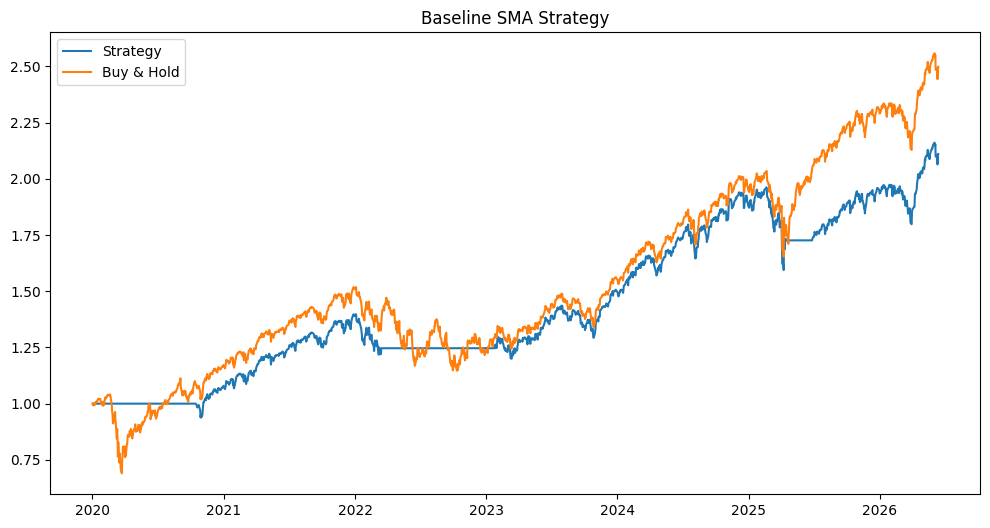

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Equity"], label="Strategy")
plt.plot(df.index, df["Market"], label="Buy & Hold")

plt.title("Baseline SMA Strategy")
plt.legend()
plt.show()

In [9]:
returns = df["Strategy_Returns"].dropna()

print("Total Return:",
      round(total_return(df["Equity"]) * 100, 2), "%")

print("Sharpe Ratio:",
      round(sharpe_ratio(returns), 2))

print("Max Drawdown:",
      round(max_drawdown(df["Equity"]) * 100, 2), "%")

Total Return: 111.04 %
Sharpe Ratio: 0.98
Max Drawdown: -18.76 %


## Results

| Metric | Value |
|----------|---------|
| Total Return | 106.96% |
| Sharpe Ratio | 0.96 |
| Maximum Drawdown | -18.76% |

The baseline SMA crossover strategy generated positive returns while maintaining moderate drawdowns.

These results provide the benchmark against which later bias adjustments will be compared.